# Actividad 2 - Clase 4 - Aprendizaje Automático

# Clasificación con Regresión Logística

El objetivo de esta actividad es predecir el sistema operativo que usa un usuario que visita un sitio web, si utiliza Windows, Macintosh o Linux. Tenemos en cuenta cuatro variables de comportamiento tomadas por Google Analytics: duración de la visita, cantidad de páginas vistas, cantidad de acciones realizadas y la suma de valor de esas acciones.

**Paso 1** Cargar el dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/gabrielasbacchiani/aprendizaje_automatico/refs/heads/main/CLASE4_AA/DATASETS/Actividad2_usuarios_win_mac_lin.csv"
df = pd.read_csv(url)

df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


El dataset fue proporcionado por la cátedra y alojado en GitHub.

**Paso 2** - Exploración

Información general del dataset

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


En el dataset hay 170 filas sin valores nulos. Como la variable a predecir es discreta (tres categorías posibles), se usan los siguientes valores:

0 = Windows
1 = Macintosh
2 = Linux

Averiguamos cuántos casos hay de cada clase:

In [3]:
df['clase'].value_counts()

,count
clase,
0,86
2,44
1,40


En este dataset, en la columna clase encontramos 3 variables, las cuales corresponden:

Clase 0 - Windows - 86

Clase 1 - Macintosh - 40

Clase 2 - Linux - 44

Podemos ver que las clases están desbalanceadas, Windows tiene más del doble de usuarios en comparación con Linux y Macintosh.

**Gráfico de Dispersión**

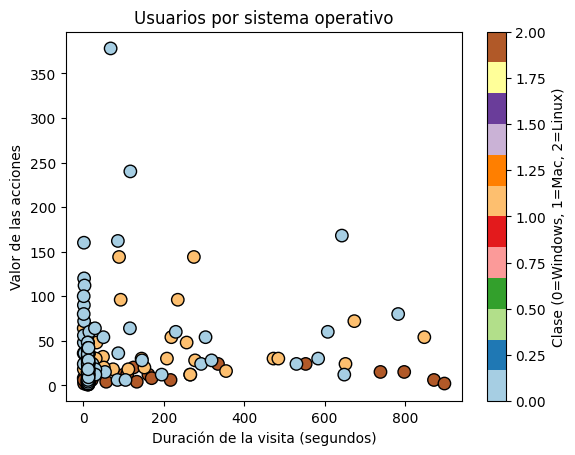

In [4]:
plt.figure()
plt.scatter(df['duracion'], df['valor'], c=df['clase'], cmap=plt.cm.Paired, s=80, edgecolors='black')
plt.xlabel('Duración de la visita (segundos)')
plt.ylabel('Valor de las acciones')
plt.title('Usuarios por sistema operativo')
plt.colorbar(label='Clase (0=Windows, 1=Mac, 2=Linux)')
plt.show()

**Paso 3** - Definir X e Y

In [5]:
X = df[['duracion', 'paginas', 'acciones', 'valor']].values
Y = df['clase'].values

print(X.shape, Y.shape)

(170, 4) (170,)


**Paso 4** - Separar entrenamiento y prueba

In [6]:
np.random.seed(0)
indices = np.random.permutation(len(X))

X = X[indices]
Y = Y[indices]

datos_entrenamiento = int(0.8 * len(X))

X_entrenamiento = X[:datos_entrenamiento]
Y_entrenamiento = Y[:datos_entrenamiento]

X_prueba = X[datos_entrenamiento:]
Y_prueba = Y[datos_entrenamiento:]

print(len(X_entrenamiento), len(X_prueba))

136 34


**Paso 5** - Entrenar la regresión logística

In [7]:
from sklearn import linear_model

clasificador = linear_model.LogisticRegression(solver='lbfgs', C=100, max_iter=1000)
clasificador.fit(X_entrenamiento, Y_entrenamiento)

LogisticRegression(C=100, max_iter=1000)

**Paso 6** - Evaluar el modelo

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

prediccion = clasificador.predict(X_prueba)

print(prediccion)
print(Y_prueba)

print("Exactitud (accuracy) =", round(accuracy_score(Y_prueba, prediccion), 2))

[1 2 1 0 2 0 1 0 0 0 0 0 2 0 0 2 1 1 0 0 0 2 0 0 0 0 1 2 1 2 0 1 2 1]
[1 2 1 0 2 0 1 0 1 1 0 0 2 0 0 0 0 1 0 0 0 2 0 0 0 0 0 2 1 2 1 0 2 1]
Exactitud (accuracy) = 0.79


El porcentaje de aciertos que tuvo el modelo es del 79 %.

A contunuación, calculamos la matriz de confusión, para mostrar que clase se confunde más:

In [9]:
matriz = confusion_matrix(Y_prueba, prediccion)
print(matriz)

[[14  3  1]
 [ 3  6  0]
 [ 0  0  7]]


Esta matriz nos muestra con precisión cuando el modelo se confundió. En la diagonal vemos los aciertos: 14 usuarios de Windows bien clasificados, 6 de Macintosh y 7 de Linux, si los sumamos 14 + 6 + 7 = 27 aciertos sobre 34 casos de prueba, que concuerda con el 79% que dio el accuracy.

Todo lo que está fuera de la diagonal son errores:

Fila "Real 0": de 18 usuarios que realmente eran Windows (14+3+1=18), el modelo acertó 14, pero confundió 3 con Macintosh y 1 con Linux.
Fila "Real 1": de 9 usuarios que realmente eran Macintosh (3+6+0=9), acertó 6, pero confundió 3 con Windows.
Fila "Real 2": de 7 usuarios que realmente eran Linux, acertó los 7, sin ningún error.

El modelo clasifica perfectamente a los usuarios de Linux (7 de 7), sin ningún error. Los errores se concentran entre Windows y Macintosh: 3 usuarios de Windows fueron confundidos con Macintosh y 3 de Macintosh con Windows. Esto coincide con el gráfico de dispersión, donde ambos grupos aparecían más mezclados entre sí, mientras que Linux se distinguía claramente por su duración de visita alta y valor de acciones bajo.

**Paso 7** - Reporte de Clasificación

In [10]:
print(classification_report(Y_prueba, prediccion))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80        18
           1       0.67      0.67      0.67         9
           2       0.88      1.00      0.93         7

    accuracy                           0.79        34
   macro avg       0.79      0.81      0.80        34
weighted avg       0.79      0.79      0.79        34



Además del accuracy general y la matriz de confusión, calculamos un reporte con tres métricas por cada clase por separado: precisión (de los que predijo como esa clase, cuántos acertó), recall o exhaustividad (de los que realmente eran esa clase, cuántos detectó) y f1-score (que combina las dos anteriores en un solo número). La columna support indica cuántos casos reales de cada clase había en el conjunto de prueba.

Esto permite ver el rendimiento del modelo con más detalle que el accuracy solo, ya que un accuracy general alto puede esconder que el modelo funciona mal para alguna clase en particular — algo relevante acá porque el dataset está desbalanceado.

Se confirma lo que mostraba la matriz de confusión: Linux tiene precisión 0,88 y recall 1,00 (el modelo lo clasifica casi perfectamente), mientras que Macintosh es la clase con peor desempeño (f1-score 0,67), coincidiendo con ser la clase con menos casos en el dataset (40 de 170).

**Paso 8** - Conclusión

El modelo de regresión logística logró un accuracy del 79% sobre el conjunto de prueba (27 de 34 usuarios clasificados correctamente).

Analizando por clase, el modelo distingue perfectamente a los usuarios de Linux (precisión 0,88, recall 1,00): ningún usuario de Linux fue mal clasificado, y solo un usuario de otra clase fue confundido con Linux. Esto coincide con lo observado en el gráfico de dispersión, donde los usuarios de Linux se agrupaban claramente por su duración de visita alta y bajo valor de acciones.

El rendimiento es más bajo para Windows (f1-score 0,80) y sobre todo para Macintosh (f1-score 0,67), que es además la clase con menos casos en el dataset (40 de 170 en total). Los errores del modelo se dan solo entre estas dos clases: la matriz de confusión muestra 3 usuarios de Windows confundidos con Macintosh y 3 de Macintosh confundidos con Windows, ningún error involucra a Linux. Esto sugiere que, con las variables disponibles (duración, páginas vistas, acciones y valor de las acciones), Windows y Macintosh tienen comportamientos de navegación más parecidos entre sí que con Linux.

Como limitación, el dataset es chico (170 registros, 34 de prueba) y está desbalanceado (más del doble de usuarios de Windows que de las otras clases), lo que hace que las métricas de Macintosh, en particular, puedan variar bastante si se repite el experimento con otra división de datos. Si tuviera más datos, sería interesante ver si agregar más ejemplos de Macintosh y Linux mejora la capacidad del modelo para distinguirlos de Windows.